In [2]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print(X_train.shape)
print(X_test.shape)
X_train.columns

(5634, 47)
(1409, 47)


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlyCharges', 'HasInternetService', 'NumServices',
       'ChargesPerService', 'ContractLevel', 'gender_Female', 'gender_Male',
       'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes',
       'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
    

In [3]:
X_cluster = pd.concat(
    [X_train, X_test],
    axis=0
).reset_index(drop=True)
print(X_cluster.shape)
print(X_cluster.dtypes)
print(X_cluster.isna().sum().sum())

(7043, 47)
SeniorCitizen                              float64
tenure                                     float64
MonthlyCharges                             float64
TotalCharges                               float64
AvgMonthlyCharges                          float64
HasInternetService                         float64
NumServices                                float64
ChargesPerService                          float64
ContractLevel                              float64
gender_Female                              float64
gender_Male                                float64
Partner_No                                 float64
Partner_Yes                                float64
Dependents_No                              float64
Dependents_Yes                             float64
PhoneService_No                            float64
PhoneService_Yes                           float64
MultipleLines_No                           float64
MultipleLines_No phone service             float64
MultipleLines_Yes   

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_cluster)
print("original features: ", X_cluster.shape[1])
print("PCA components: ", X_pca.shape[1])

print("explained variance : ", pca.explained_variance_ratio_.sum())

original features:  47
PCA components:  17
explained variance :  0.9534019826168545


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score


metrics_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_pca)
    metrics_scores.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_pca, labels),
        'calinski_h': calinski_harabasz_score(X_pca, labels) 
    })
    
print(pd.DataFrame(metrics_scores))

    k       inertia  silhouette   calinski_h
0   2  80256.724684    0.314985  2874.790103
1   3  61375.388863    0.285215  2962.206977
2   4  55911.573916    0.240887  2396.783645
3   5  51158.526710    0.233977  2127.778488
4   6  48164.334358    0.233434  1895.284497
5   7  45682.500329    0.226962  1728.676684
6   8  43319.299655    0.184538  1617.159152
7   9  41707.128969    0.185407  1503.492026
8  10  40529.818151    0.171552  1397.769514


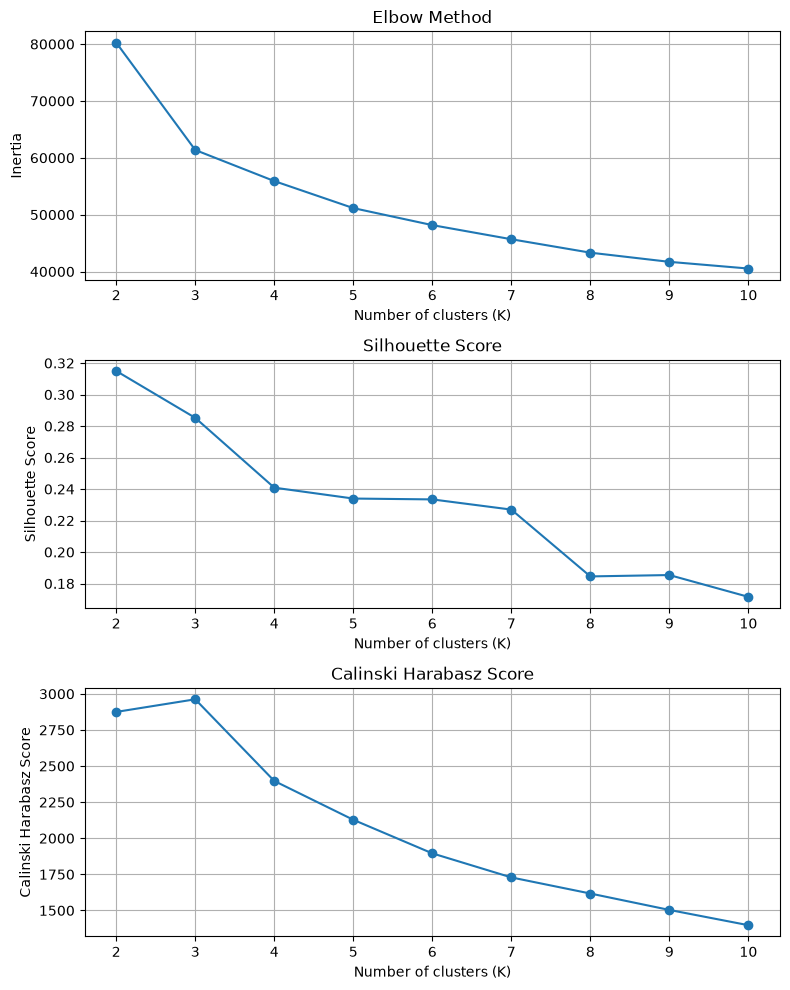

In [24]:
import matplotlib.pyplot as plt

k_values = [item["k"] for item in metrics_scores]

inertia_values = [
    item["inertia"]
    for item in metrics_scores
]

silhouette_values = [
    item["silhouette"]
    for item in metrics_scores
]
calinski_harabasz_values = [
    item["calinski_h"] for item in metrics_scores
]
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 10)
)

axes[0].plot(
    k_values,
    inertia_values,
    marker="o"
)

axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid(True)


axes[1].plot(
    k_values,
    silhouette_values,
    marker="o"
)

axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].grid(True)

axes[2].plot(
    k_values,
    calinski_harabasz_values,
    marker="o"
)

axes[2].set_xlabel("Number of clusters (K)")
axes[2].set_ylabel("Calinski Harabasz Score")
axes[2].set_title("Calinski Harabasz Score")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [7]:
#based on the plots k=3 is the beginning of a smaller decreasing of inertia , also the silhouette score is high

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(X_pca)
X_cluster["Cluster"] = cluster_labels
print(X_cluster["Cluster"].value_counts().sort_index())

Cluster
0    1526
1    3131
2    2386
Name: count, dtype: int64


In [8]:
y_cluster = pd.concat(
    [y_train, y_test],
    axis=0
    ).reset_index(drop=True).squeeze()
cluster_analysis = pd.DataFrame({
    "Cluster": cluster_labels,
    "Churn": y_cluster
})

print(cluster_analysis.head())
print(cluster_analysis.shape)

   Cluster  Churn
0        1      0
1        1      0
2        1      0
3        2      0
4        1      0
(7043, 2)


In [27]:
print(
   ( cluster_analysis.groupby("Cluster")["Churn"].mean()) * 100
)

Cluster
0     7.404980
1    43.468540
2    16.554904
Name: Churn, dtype: float64


In [21]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_pca)

In [22]:
import numpy as np

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)
for label, count in zip(unique_labels, counts):
    print(f"cluster {label}: {count} customers")

cluster -1: 30 customers
cluster 0: 4424 customers
cluster 1: 1474 customers
cluster 2: 1063 customers
cluster 3: 52 customers


In [ ]:
X_cluster["Cluster"] = cluster_labels
print(X_cluster.head())

   SeniorCitizen    tenure  ...  PaymentMethod_Mailed check  Cluster
0      -0.441773  0.102371  ...                         0.0        1
1      -0.441773 -0.711743  ...                         1.0        1
2      -0.441773 -0.793155  ...                         1.0        1
3      -0.441773 -0.263980  ...                         0.0        2
4      -0.441773 -1.281624  ...                         0.0        1

[5 rows x 48 columns]


In [35]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

cluster_profile = (
    X_cluster
    .groupby("Cluster")[numeric_features]
    .mean()
    .round(2)
)

print(cluster_profile)

         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         -0.08           -1.46         -0.72
1         -0.66            0.06         -0.55
2          0.90            0.84          1.15
